# Two Moons Inverse Problem — HMC vs Annealed HMC vs SMC

## Setup
- **Prior** `p(z)`: Two Moons distribution, learned by a RealNVP flow.
- **Forward model**: `y = z₁ + noise`,  `A = [[1, 0]]` — observe only the first coordinate.
- **Ground truth `z†`** is chosen in the *overlap* region (`z₁ ≈ 0.5`) so the posterior is **bimodal**: one mode on each moon.

## Three samplers
| Method | Mode mixing? | Exact? |
|--------|-------------|--------|
| **(a) Vanilla HMC** | ✗ — single chain, gets trapped | ✓ (if mixes) |
| **(b) Annealed HMC** | ✓ (better) — broad likelihood smooths barriers | ✗ biased |
| **(c) SMC** | ✓ — particle ensemble covers all modes from the start | ✓ asymptotically |

In [1]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

sys.path.insert(0, '.')

from flow_model import RealNVP, train_flow, verify_flow
from log_posterior import LogPosterior
from forward_models import (
    sample_two_moons,
    make_partial_observation, make_noisy_observation,
    identity_decoder,
)
from samplers import (
    HMCSampler, SMCSampler,
    run_annealed_hmc, make_adaptive_sigma_schedule,
    compute_ess,
)
from validation import compute_analytical_posterior_grid, coverage_test

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

torch.manual_seed(0)
np.random.seed(0)

# Display limits — two moons live in roughly [-1.2, 2.2] x [-0.7, 1.2]
XLIM = (-1.8, 2.8)
YLIM = (-1.2, 1.8)
GRID_RANGE = (-2.5, 3.0)   # square grid that covers both moons

Device: cpu


---
## Step 1 — Train a RealNVP Flow on Two Moons

In [2]:
target_samples = sample_two_moons(30000, noise=0.08, device=device)

flow = RealNVP(dim=2, hidden_dim=128, n_layers=12).to(device)
losses = train_flow(flow, target_samples, n_epochs=3000, lr=1e-3)

print('\n=== Flow Verification ===')
verify_flow(flow)

Epoch 200/3000, NLL: 0.7977
Epoch 400/3000, NLL: 0.7914
Epoch 600/3000, NLL: 0.7852
Epoch 800/3000, NLL: 0.7808
Epoch 1000/3000, NLL: 0.7836
Epoch 1200/3000, NLL: 0.7781
Epoch 1400/3000, NLL: 0.7770
Epoch 1600/3000, NLL: 0.7739
Epoch 1800/3000, NLL: 0.7732
Epoch 2000/3000, NLL: 0.7709
Epoch 2200/3000, NLL: 0.7687
Epoch 2400/3000, NLL: 0.7662
Epoch 2600/3000, NLL: 0.7644
Epoch 2800/3000, NLL: 0.7640
Epoch 3000/3000, NLL: 0.7636

=== Flow Verification ===
  Max invertibility error: 2.58e-03
  Sample mean: [0.520, 0.248]
  Sample std:  [0.867, 0.498]
  Flow verification PASSED


{'max_error': 0.0025751590728759766,
 'mean': tensor([0.5198, 0.2483]),
 'std': tensor([0.8667, 0.4978]),
 'ok': True}

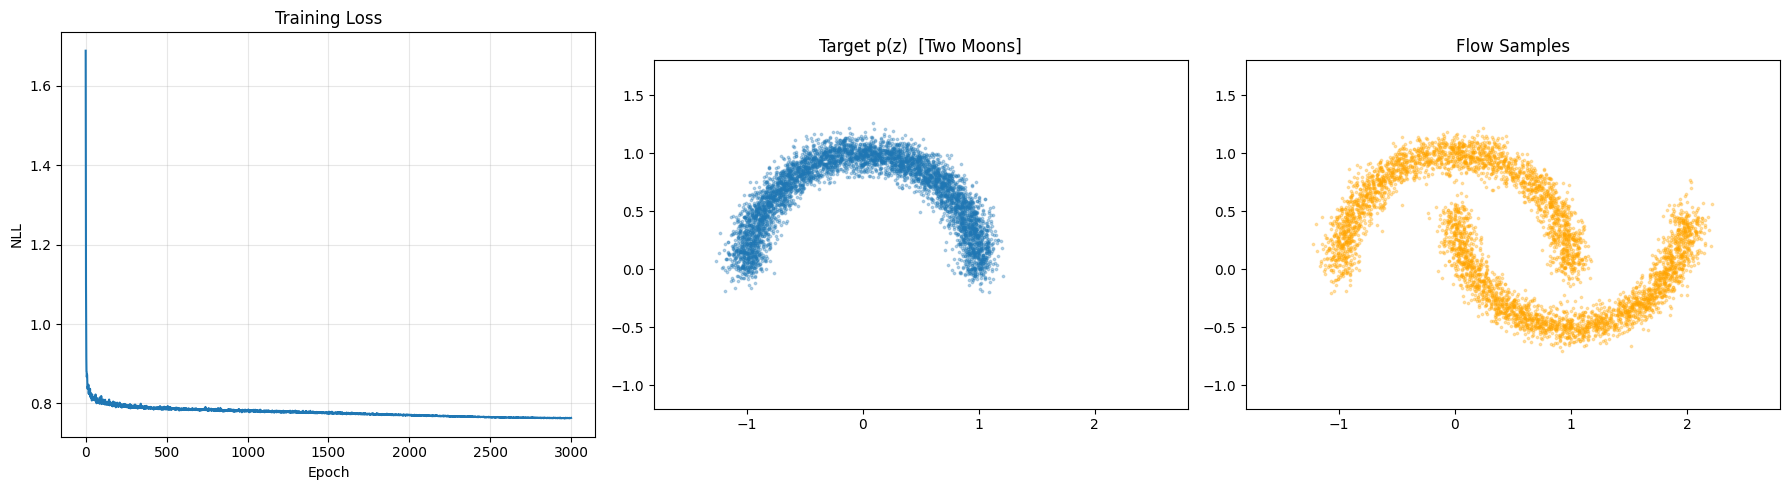

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(losses)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('NLL')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

with torch.no_grad():
    flow_samples = flow.sample(5000).cpu().numpy()
target_np = target_samples[:5000].cpu().numpy()

axes[1].scatter(target_np[:, 0], target_np[:, 1], alpha=0.3, s=3)
axes[1].set_title('Target p(z)  [Two Moons]')
axes[1].set_xlim(*XLIM); axes[1].set_ylim(*YLIM); axes[1].set_aspect('equal')

axes[2].scatter(flow_samples[:, 0], flow_samples[:, 1], alpha=0.3, s=3, c='orange')
axes[2].set_title('Flow Samples')
axes[2].set_xlim(*XLIM); axes[2].set_ylim(*YLIM); axes[2].set_aspect('equal')

plt.tight_layout(); plt.show()

---
## Step 2 — Set Up Inverse Problem

Forward model: `y = z₁ + noise`  (A projects onto the first coordinate)

We pick `z†` from the *overlap region* (`z₁ ≈ 0.5`) so the posterior has **two modes** — one on each moon.

In [4]:
A = torch.tensor([[1.0, 0.0]], device=device)
forward_op = make_partial_observation(A)
decoder = identity_decoder
sigma_n = 0.05   # tight likelihood → sharp posterior modes

# Pick z_true from the upper moon in the overlap region (z1 ≈ 0.5)
# This guarantees both moons contribute a posterior mode
candidates = target_samples[
    (target_samples[:, 0] > 0.35) &
    (target_samples[:, 0] < 0.65) &
    (target_samples[:, 1] > 0.5)   # upper moon
]
torch.manual_seed(7)
z_true = candidates[torch.randint(0, len(candidates), (1,)).item()]
y_obs  = make_noisy_observation(forward_op, z_true, sigma_n, seed=42)

print(f'Ground truth z†: {z_true.cpu().numpy().round(4)}')
print(f'Observation y:   {y_obs.cpu().numpy().round(4)}')
print(f'sigma_n:         {sigma_n}')
print(f'\nAt z1≈{y_obs.item():.2f}:')
print(f'  Upper moon z2 ≈  sin(arccos({y_obs.item():.2f})) ≈ {np.sin(np.arccos(y_obs.item())):.3f}')
print(f'  Lower moon z2 ≈  1 - sin(arccos({y_obs.item():.2f})) - 0.5 ≈ {1-np.sin(np.arccos(y_obs.item()))-0.5:.3f}')
print('=> Two posterior modes expected!')

Ground truth z†: [0.5083 0.8425]
Observation y:   [0.5251]
sigma_n:         0.05

At z1≈0.53:
  Upper moon z2 ≈  sin(arccos(0.53)) ≈ 0.851
  Lower moon z2 ≈  1 - sin(arccos(0.53)) - 0.5 ≈ -0.351
=> Two posterior modes expected!


---
## Step 3 — Analytical Posterior on Grid

Using `flow.log_prob(z)` as the prior, so this is the exact posterior under the learned prior.

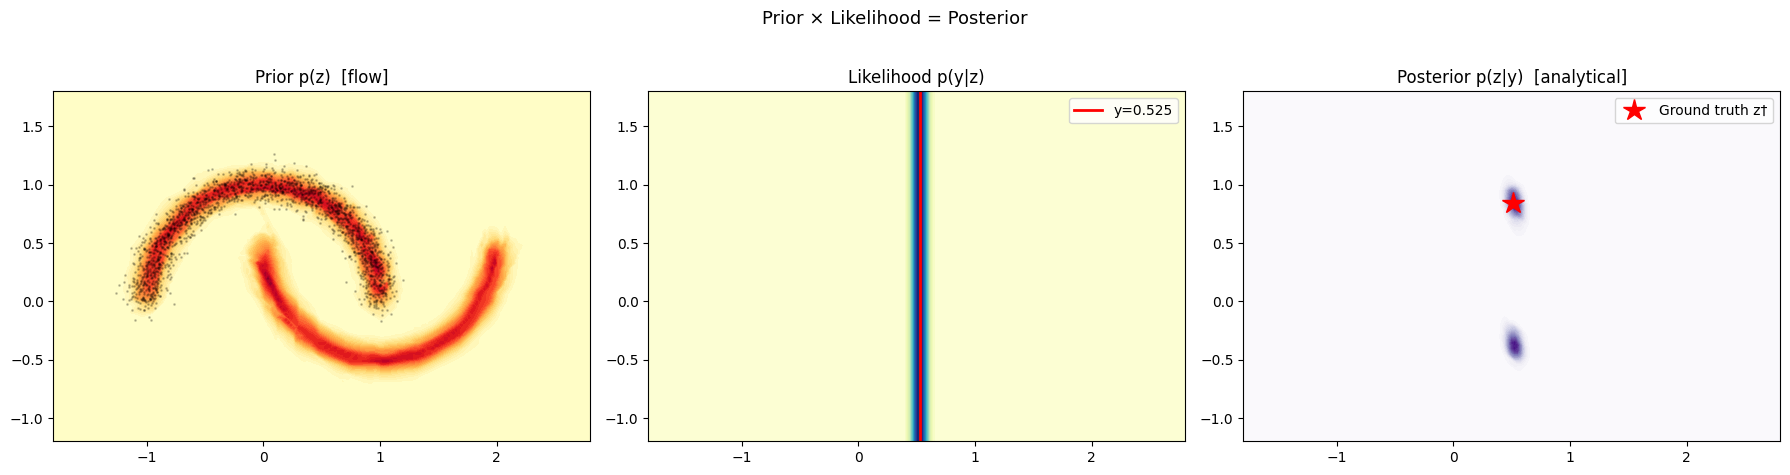

In [5]:
analytical = compute_analytical_posterior_grid(
    flow, forward_op, y_obs, sigma_n, A,
    grid_range=GRID_RANGE, grid_size=250, device=device,
)
xx, yy = analytical['xx'], analytical['yy']
z_true_np = z_true.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].contourf(xx, yy, np.exp(analytical['log_prior']), levels=30, cmap='YlOrRd')
axes[0].scatter(target_np[:2000,0], target_np[:2000,1], s=1, alpha=0.2, c='k')
axes[0].set_title('Prior p(z)  [flow]')
axes[0].set_xlim(*XLIM); axes[0].set_ylim(*YLIM); axes[0].set_aspect('equal')

ll = analytical['log_likelihood']
axes[1].contourf(xx, yy, np.exp(ll - ll.max()), levels=30, cmap='YlGnBu')
axes[1].axvline(x=y_obs.cpu().item(), color='red', lw=2, label=f'y={y_obs.cpu().item():.3f}')
axes[1].set_title('Likelihood p(y|z)')
axes[1].set_xlim(*XLIM); axes[1].set_ylim(*YLIM); axes[1].set_aspect('equal')
axes[1].legend()

axes[2].contourf(xx, yy, analytical['posterior'], levels=30, cmap='Purples')
axes[2].plot(*z_true_np, 'r*', markersize=16, label='Ground truth z†')
axes[2].set_title('Posterior p(z|y)  [analytical]')
axes[2].set_xlim(*XLIM); axes[2].set_ylim(*YLIM); axes[2].set_aspect('equal')
axes[2].legend()

plt.suptitle('Prior × Likelihood = Posterior', fontsize=13)
plt.tight_layout(); plt.show()

---
## Step 4a — (a) Vanilla HMC

Single chain initialised at `z_guess = (y_obs, 0)` — in the valley between the two moons.
Expected: chain gets trapped in whichever mode it wanders into first.

In [6]:
flow_inverse = lambda eps: flow.inverse(eps.unsqueeze(0)).squeeze(0)

log_posterior = LogPosterior(
    flow_inverse=flow_inverse,
    decoder=decoder,
    forward_op=forward_op,
    y=y_obs,
    sigma_n=sigma_n,
)

# Initialise at z_guess = (y_obs, 0)  ->  map to eps-space
z_init = torch.zeros(2, device=device)
z_init[0] = y_obs.squeeze()
with torch.no_grad():
    eps_init, _ = flow.forward(z_init.unsqueeze(0))
    eps_init = eps_init.squeeze(0)

hmc = HMCSampler(log_posterior, dim=2, step_size=None, n_leapfrog=30)
eps_hmc, info_hmc = hmc.sample(eps_init, n_samples=1500, n_warmup=500, verbose=True)

with torch.no_grad():
    z_hmc = flow.inverse(eps_hmc).cpu().numpy()

ess_hmc = compute_ess(eps_hmc)
print(f'\nAcceptance: {info_hmc["acceptance_rate"]:.3f}')
print(f'ESS: [{ess_hmc[0]:.0f}, {ess_hmc[1]:.0f}]')
print(f'Posterior mean: {z_hmc.mean(0).round(3)}')

  Auto step size: 0.144533


HMC:  25%|██▌       | 504/2000 [00:18<00:56, 26.46it/s]

  Adapted step size: 0.018118


HMC: 100%|██████████| 2000/2000 [01:13<00:00, 27.29it/s]


Acceptance: 0.569
ESS: [12, 13]
Posterior mean: [ 0.522 -0.339]


---
## Step 4b — (b) Annealed HMC with Adaptive Sigma Schedule

`make_adaptive_sigma_schedule` runs the same ESS-based bisection as SMC's beta selector but for a single chain:
it draws test particles from N(0,I), evaluates their log likelihoods, and finds the
coarsest sigma schedule where the incremental ESS stays above 90%.

In [50]:
# log_likelihood_fn: just the likelihood term (prior handled separately)
def log_likelihood_fn(eps):
    z = flow_inverse(eps)
    pred = forward_op(decoder(z))
    return -0.5 * ((y_obs - pred) ** 2).sum() / (sigma_n ** 2)

def log_posterior_factory(sigma_eff):
    return LogPosterior(
        flow_inverse=flow_inverse,
        decoder=decoder,
        forward_op=forward_op,
        y=y_obs,
        sigma_n=sigma_eff,
    )

# Auto-compute the sigma schedule
# sigma_schedule = make_adaptive_sigma_schedule(
#     log_likelihood_fn, sigma_n=sigma_n, dim=2,
#     n_test=300, target_ess=0.9, device=device,
# )

# sigma_schedule = [1.001, 0.501, 0.151, 0.100, 0.079]
sigma_schedule = [0.201]
print(f'Adaptive sigma schedule ({len(sigma_schedule)} stages):')
print('  ' + ' → '.join(f'{s:.3f}' for s in sigma_schedule))

Adaptive sigma schedule (1 stages):
  0.201


In [51]:
annealed = run_annealed_hmc(
    log_posterior_factory=log_posterior_factory,
    eps_init=eps_init,
    sigma_schedule=sigma_schedule,
    n_samples_per_stage=200,
    n_warmup_per_stage=150,
    n_leapfrog=20,
    verbose=True,
)

eps_ann = annealed['final_samples']
with torch.no_grad():
    z_ann = flow.inverse(eps_ann).cpu().numpy()

ess_ann = compute_ess(eps_ann)
print(f'\nFinal stage ESS: [{ess_ann[0]:.0f}, {ess_ann[1]:.0f}]')
print(f'Posterior mean: {z_ann.mean(0).round(3)}')


  Stage 1/1: sigma_eff=0.2010
  Auto step size: 0.144533


HMC:  44%|████▍     | 154/350 [00:03<00:04, 39.52it/s]

  Adapted step size: 0.041757


HMC: 100%|██████████| 350/350 [00:08<00:00, 38.95it/s]

    acceptance=0.691  step=0.04176  ESS=[17, 7]

Final stage ESS: [17, 7]
Posterior mean: [ 0.495 -0.131]


---
## Step 4c — (c) SMC

Particles initialised from the prior `N(0,I)` which already covers both moons.
Importance weights and resampling prevent collapse; HMC rejuvenation diversifies particles at each temperature.

In [11]:
smc = SMCSampler(
    log_likelihood_fn=log_likelihood_fn,
    dim=2,
    n_particles=400,
    n_mcmc_steps=5,
    n_leapfrog=10,
    ess_threshold=0.5,
)

smc_result = smc.sample(device=device, verbose=True)

eps_smc = smc_result['samples']
with torch.no_grad():
    z_smc = flow.inverse(eps_smc).cpu().numpy()

print(f'\nSMC: {smc_result["n_stages"]} stages')
print(f'log p(y) estimate: {smc_result["log_normalizer"]:.3f}')
print(f'Posterior mean: {z_smc.mean(0).round(3)}')

  SMC: 400 particles, 5 HMC moves/particle/stage
  Initialising particles from prior N(0,I)...
  Stage   1: β=0.0024  Δβ=0.0024  ESS=0.90            acc=0.78  step=0.18446
  Stage   2: β=0.0063  Δβ=0.0039  ESS=0.81            acc=0.61  step=0.18446
  Stage   3: β=0.0133  Δβ=0.0070  ESS=0.73            acc=0.44  step=0.18446
  Stage   4: β=0.0246  Δβ=0.0113  ESS=0.67            acc=0.27  step=0.14757
  Stage   5: β=0.0402  Δβ=0.0156  ESS=0.61            acc=0.28  step=0.11805
  Stage   6: β=0.0592  Δβ=0.0190  ESS=0.57            acc=0.30  step=0.11805
  Stage   7: β=0.0841  Δβ=0.0249  ESS=0.52            acc=0.24  step=0.09444
  Stage   8: β=0.1136  Δβ=0.0295  ESS=0.48  RESAMPLE  acc=0.29  step=0.07555
  Stage   9: β=0.1970  Δβ=0.0835  ESS=0.90            acc=0.26  step=0.06044
  Stage  10: β=0.2996  Δβ=0.1025  ESS=0.80            acc=0.28  step=0.04836
  Stage  11: β=0.4239  Δβ=0.1244  ESS=0.73            acc=0.33  step=0.04836
  Stage  12: β=0.5656  Δβ=0.1417  ESS=0.68            acc=

---
## Step 5 — Three-Way Comparison

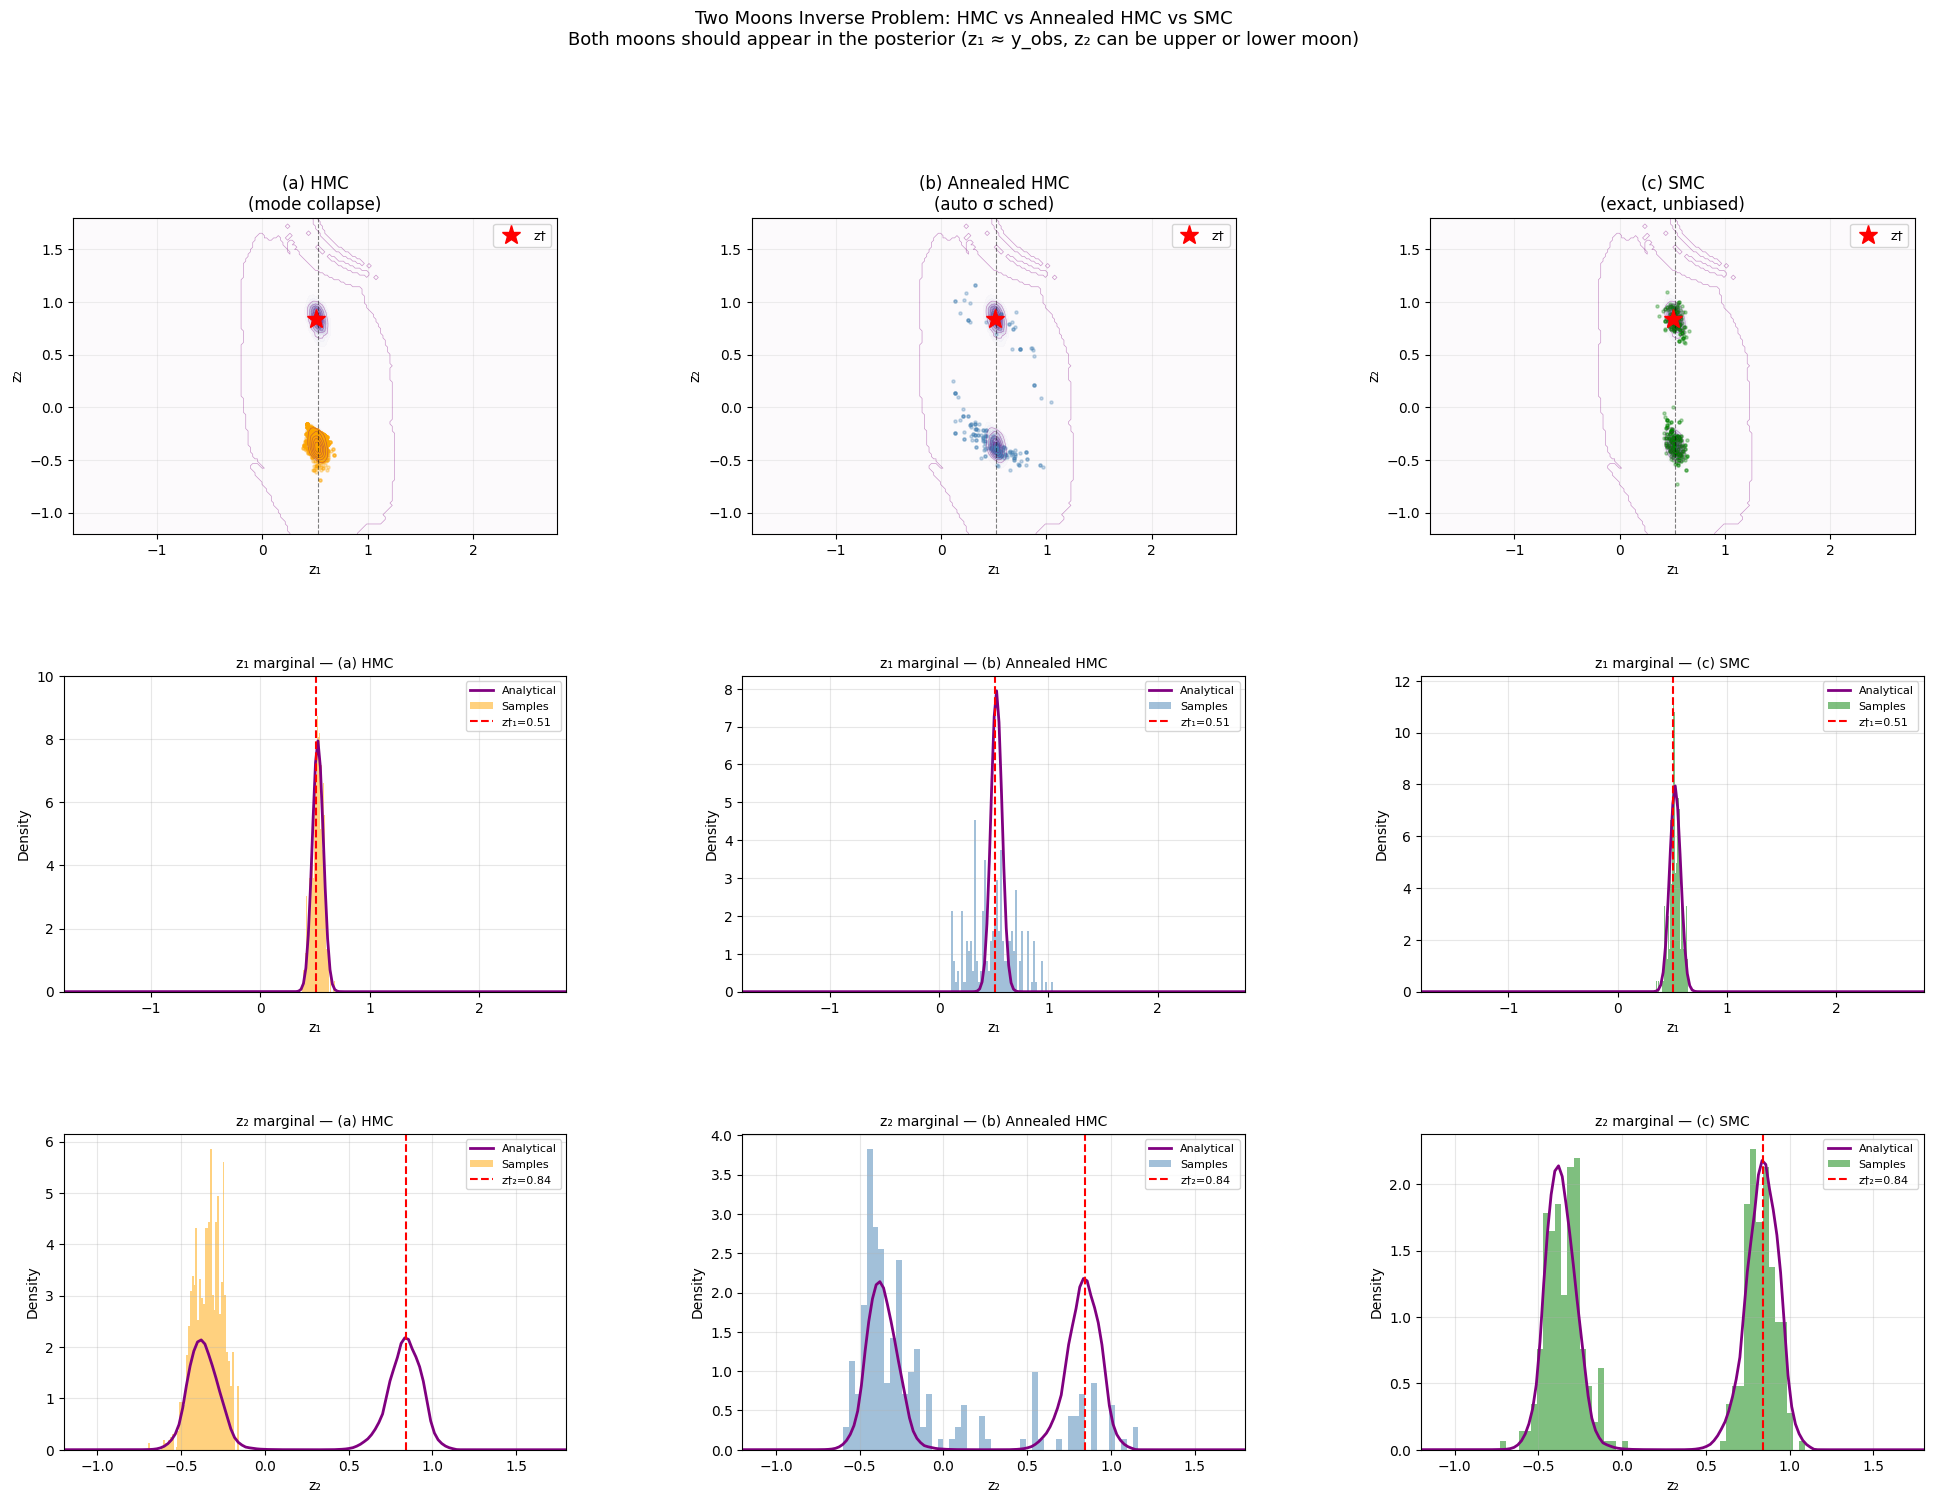

Saved: two_moons_comparison.png


In [62]:
fig = plt.figure(figsize=(24, 16))
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

methods = [
    ('(a) HMC\n(mode collapse)',      z_hmc,  'orange',    info_hmc),
    ('(b) Annealed HMC\n(auto σ sched)', z_ann, 'steelblue', annealed['stage_infos'][-1]),
    ('(c) SMC\n(exact, unbiased)',    z_smc,  'green',     None),
]

# ---- Row 0: Posterior overlays ----
for col, (title, z_s, color, info) in enumerate(methods):
    ax = fig.add_subplot(gs[0, col])
    ax.contourf(xx, yy, analytical['posterior'], levels=20, cmap='Purples', alpha=0.6)
    ax.contour(xx, yy, analytical['posterior'],  levels=6,  colors='purple', linewidths=0.5, alpha=0.4)
    ax.scatter(z_s[:, 0], z_s[:, 1], alpha=0.3, s=5, c=color)
    ax.plot(*z_true_np, 'r*', markersize=14, label='z†', zorder=5)
    ax.axvline(x=y_obs.cpu().item(), color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect('equal')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

# ---- Row 1: z1 marginal ----
z1g = analytical['z1_grid']
for col, (title, z_s, color, info) in enumerate(methods):
    ax = fig.add_subplot(gs[1, col])
    ax.plot(z1g, analytical['z1_marginal'], 'purple', lw=2, label='Analytical')
    ax.hist(z_s[:, 0], bins=50, density=True, alpha=0.5, color=color, label='Samples')
    ax.axvline(x=z_true_np[0], color='red', lw=1.5, linestyle='--', label=f'z†₁={z_true_np[0]:.2f}')
    ax.set_xlabel('z₁'); ax.set_ylabel('Density')
    ax.set_title(f'z₁ marginal — {title.split(chr(10))[0]}', fontsize=10)
    ax.set_xlim(*XLIM); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ---- Row 2: z2 marginal ----
z2g = analytical['z2_grid']
for col, (title, z_s, color, info) in enumerate(methods):
    ax = fig.add_subplot(gs[2, col])
    ax.plot(z2g, analytical['z2_marginal'], 'purple', lw=2, label='Analytical')
    ax.hist(z_s[:, 1], bins=50, density=True, alpha=0.5, color=color, label='Samples')
    ax.axvline(x=z_true_np[1], color='red', lw=1.5, linestyle='--', label=f'z†₂={z_true_np[1]:.2f}')
    ax.set_xlabel('z₂'); ax.set_ylabel('Density')
    ax.set_title(f'z₂ marginal — {title.split(chr(10))[0]}', fontsize=10)
    ax.set_xlim(*YLIM); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle(
    'Two Moons Inverse Problem: HMC vs Annealed HMC vs SMC\n'
    'Both moons should appear in the posterior (z₁ ≈ y_obs, z₂ can be upper or lower moon)',
    fontsize=13, y=1.01
)
plt.savefig('two_moons_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: two_moons_comparison.png')

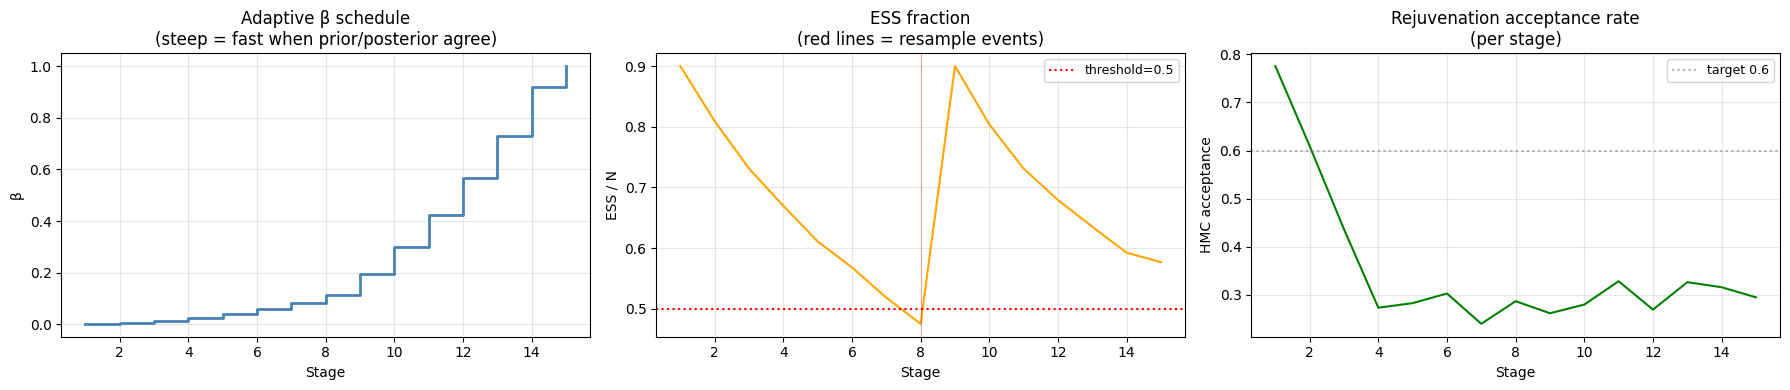

In [53]:
# ---- SMC diagnostic: beta schedule and ESS trajectory ----
diags = smc_result['diagnostics']
stages   = [d['stage']      for d in diags]
betas    = [d['beta']       for d in diags]
ess_f    = [d['ess_frac']   for d in diags]
acc      = [d['acceptance'] for d in diags]
resample = [d['stage'] for d in diags if d['resampled']]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Beta schedule
axes[0].step(stages, betas, where='post', color='steelblue', lw=2)
axes[0].set_xlabel('Stage'); axes[0].set_ylabel('β')
axes[0].set_title('Adaptive β schedule\n(steep = fast when prior/posterior agree)')
axes[0].grid(True, alpha=0.3)

# ESS
axes[1].plot(stages, ess_f, 'orange', lw=1.5)
axes[1].axhline(y=smc.ess_threshold, color='red', linestyle=':', label=f'threshold={smc.ess_threshold}')
for s in resample:
    axes[1].axvline(x=s, color='red', alpha=0.3, lw=0.8)
axes[1].set_xlabel('Stage'); axes[1].set_ylabel('ESS / N')
axes[1].set_title('ESS fraction\n(red lines = resample events)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# Acceptance
axes[2].plot(stages, acc, 'green', lw=1.5)
axes[2].axhline(y=0.6, color='gray', linestyle=':', alpha=0.6, label='target 0.6')
axes[2].set_xlabel('Stage'); axes[2].set_ylabel('HMC acceptance')
axes[2].set_title('Rejuvenation acceptance rate\n(per stage)')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## Summary

| | HMC | Annealed HMC | SMC |
|---|---|---|---|
| **Finds both modes** | ✗ | Sometimes | ✓ |
| **Exact samples** | ✓ (if mixed) | ✗ biased | ✓ asymptotically |
| **log p(y) estimate** | ✗ | ✗ | ✓ |
| **Cost** | Low | Medium | High (N × stages) |

### Key takeaway
- The eps-space reformulation (NSPS) does NOT solve mode mixing — it just moves the modes to eps-space.
- **SMC** solves mode mixing by initialising a particle ensemble from the prior (which covers all modes at β=0) and using importance weights + resampling to steer particles toward the posterior without ever losing any mode.
- **Annealed HMC** helps vs vanilla HMC but remains a single chain — whether it crosses between modes depends on whether the annealing path is smooth enough. It gives biased samples.
- For downstream inverse problems (e.g. Flux + SR/inpainting), SMC is the correct approach when the posterior is multimodal.

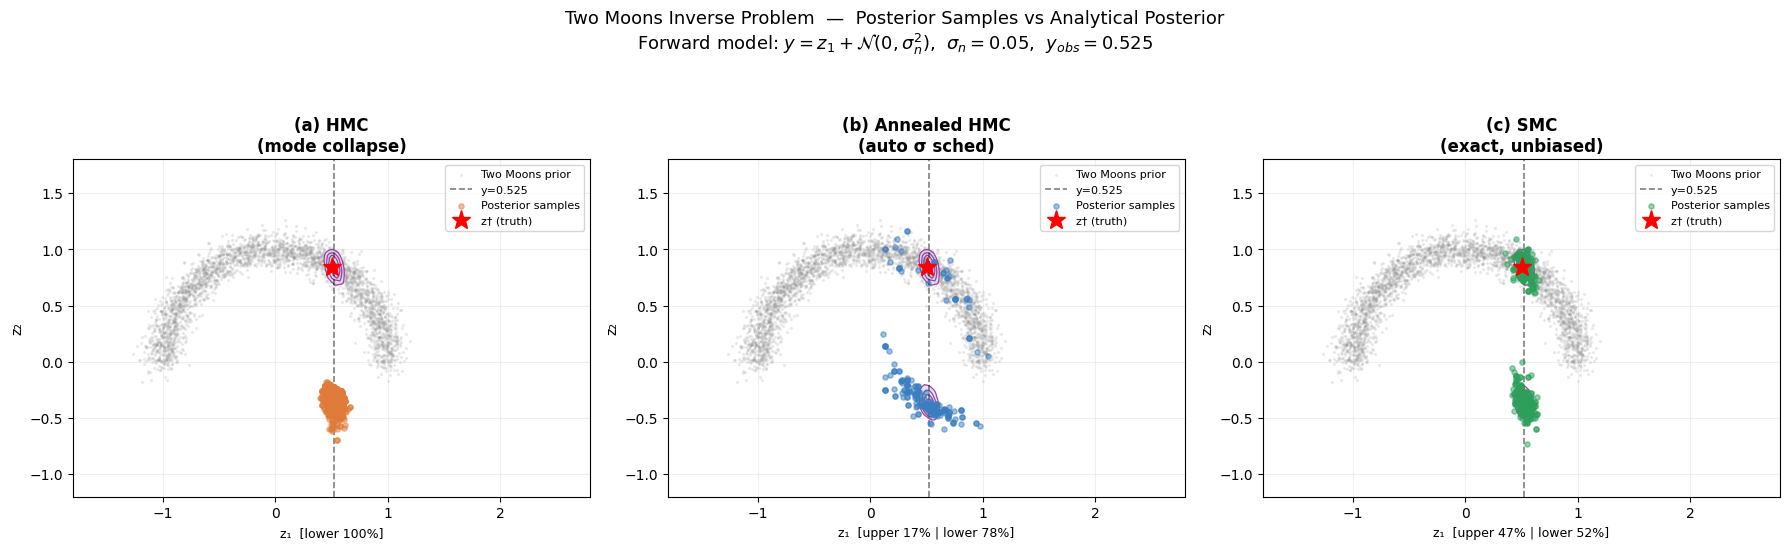

Saved: two_moons_1x3.png


In [60]:
# ── 1 × 3  Two-Moons Posterior Comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

configs = [
    dict(label='(a) HMC\n(mode collapse)',          samples=z_hmc, color='#E07B3A', n_show=800),
    dict(label='(b) Annealed HMC\n(auto σ sched)',  samples=z_ann, color='#3A7EC0', n_show=800),
    dict(label='(c) SMC\n(exact, unbiased)',         samples=z_smc, color='#2CA05A', n_show=400),
]

# Only show the top 80% of the posterior max — drops the large diffuse tail blob
p = analytical['posterior']
high_levels = np.linspace(0.20 * p.max(), p.max(), 5)

for ax, cfg in zip(axes, configs):
    z_s = cfg['samples']

    # ── background: target (two moons) distribution ──
    ax.scatter(
        target_np[:3000, 0], target_np[:3000, 1],
        s=2, alpha=0.12, c='#888888', zorder=1, label='Two Moons prior'
    )

    # ── analytical posterior: filled region + contours (high-density only) ──
    ax.contourf(xx, yy, p, levels=[high_levels[0], p.max()],
                colors=['#DDD8F0'], alpha=0.7, zorder=1)
    ax.contour(xx, yy, p, levels=high_levels,
               colors='purple', linewidths=0.9, alpha=0.7, zorder=2)

    # ── observation slice ──
    ax.axvline(x=y_obs.cpu().item(), color='black', lw=1.2,
               linestyle='--', alpha=0.5, zorder=3, label=f'y={y_obs.cpu().item():.3f}')

    # ── posterior samples ──
    n = min(cfg['n_show'], len(z_s))
    ax.scatter(z_s[:n, 0], z_s[:n, 1],
               s=14, alpha=0.5, c=cfg['color'], zorder=4, label='Posterior samples')

    # ── ground truth ──
    ax.plot(*z_true_np, 'r*', markersize=14, zorder=5, label='z† (truth)')

    # ── mode coverage annotation ──
    upper = (z_s[:, 1] > 0.3).mean()
    lower = (z_s[:, 1] < 0.0).mean()
    mode_str = []
    if upper > 0.05: mode_str.append(f'upper {upper:.0%}')
    if lower > 0.05: mode_str.append(f'lower {lower:.0%}')
    mode_info = ' | '.join(mode_str) if mode_str else 'mode collapse'

    ax.set_title(cfg['label'], fontsize=12, fontweight='bold')
    ax.set_xlabel(f'z₁  [{mode_info}]', fontsize=9)
    ax.set_ylabel('z₂', fontsize=10)
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'Two Moons Inverse Problem  —  Posterior Samples vs Analytical Posterior\n'
    r'Forward model: $y = z_1 + \mathcal{N}(0,\sigma_n^2)$,  '
    f'$\\sigma_n={sigma_n}$,  $y_{{obs}}={y_obs.cpu().item():.3f}$',
    fontsize=13
)
plt.tight_layout()
plt.savefig('two_moons_1x3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: two_moons_1x3.png')